# Navigation — DQN agent for the Unity Banana environment

This notebook drives the agent end-to-end:

1. Connect to the Unity Banana environment (downloaded separately).
2. Inspect the action and state spaces.
3. Train a Double-DQN + Dueling Q-network agent until the rolling-100
   episode score crosses **+13** (the project's solve criterion).
4. Plot the learning curve.
5. Reload the saved weights and watch a trained episode.

The agent and Q-network live in `agent.py` and `model.py` next to this
notebook.

In [1]:
import os
import sys
from collections import deque
from time import time

# Make the Udacity DRLND unityagents fork importable. The standard pip
# unityagents 0.4.0 pins tensorflow==1.7.1 which is unavailable for
# Python>=3.7 on Apple Silicon, so we use the tensorflow-free fork that
# ships in the udacity/deep-reinforcement-learning repo's `python/`
# directory (https://github.com/udacity/deep-reinforcement-learning).
sys.path.insert(0, '/tmp/drlnd/python')

import numpy as np
import torch
import matplotlib.pyplot as plt

from unityagents import UnityEnvironment

from agent import DQNAgent

%matplotlib inline


## 1. Connect to the environment

Download the Banana env binary that matches your OS from the Udacity project page and point `file_name` to the executable.

In [2]:
# Connect to the Banana env. file_name points at the Mac build extracted
# from Banana.app.zip; on Linux you would point at
# 'Banana_Linux/Banana.x86_64' instead. no_graphics=True keeps the env
# headless so the notebook can be re-executed unattended.
env = UnityEnvironment(file_name='/tmp/banana-env/Banana.app', no_graphics=True)
brain_name = env.brain_names[0]
brain      = env.brains[brain_name]

env_info  = env.reset(train_mode=True)[brain_name]
state     = env_info.vector_observations[0]
state_size  = len(state)
action_size = brain.vector_action_space_size
print(f'state_size  = {state_size}')
print(f'action_size = {action_size}')


Mono path[0] = '/tmp/banana-env/Banana.app/Contents/Resources/Data/Managed'
Mono config path = '/tmp/banana-env/Banana.app/Contents/MonoBleedingEdge/etc'


INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: BananaBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 37
        Number of stacked Vector Observation: 1
        Vector Action space type: discrete
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


state_size  = 37
action_size = 4


## 2. Train the agent

Hyper-parameters (all in `agent.py`):

| | |
|---|---|
| `buffer_size` | 100 000 |
| `batch_size`  | 64 |
| `gamma`       | 0.99 |
| `tau`         | 1e-3 |
| `lr`          | 5e-4 |
| `update_every`| 4 steps |
| `dueling`     | True |
| `double_dqn`  | True |
| ε start / min / decay | 1.0 / 0.01 / 0.995 |

In [3]:
def dqn(n_episodes=2000, eps_start=1.0, eps_end=0.01, eps_decay=0.995,
        target_score=13.0):
    agent = DQNAgent(state_size=state_size, action_size=action_size)
    scores_window = deque(maxlen=100)
    all_scores = []
    eps = eps_start
    started = time()
    for episode in range(1, n_episodes + 1):
        env_info = env.reset(train_mode=True)[brain_name]
        state    = env_info.vector_observations[0]
        score    = 0.0
        while True:
            action = agent.act(state, eps)
            env_info = env.step(action)[brain_name]
            next_state = env_info.vector_observations[0]
            reward     = env_info.rewards[0]
            done       = env_info.local_done[0]
            agent.step(state, action, reward, next_state, int(done))
            state, score = next_state, score + reward
            if done:
                break
        eps = max(eps_end, eps_decay * eps)
        scores_window.append(score); all_scores.append(score)
        avg = np.mean(scores_window)
        print(f'\rEp {episode:4d}\tscore={score:.1f}\trolling100={avg:.2f}\teps={eps:.3f}', end='')
        if episode % 100 == 0:
            print(f'\n[Episode {episode:4d}]  rolling-100 mean = {avg:.2f}  ({time() - started:.0f}s elapsed)')
        if avg >= target_score and len(scores_window) == 100:
            print(f'\n\nSolved in {episode} episodes — saving banana_qnet.pth.')
            torch.save(agent.qnet_local.state_dict(), 'banana_dqn.pth')
            return agent, all_scores
    return agent, all_scores

agent, scores = dqn()

Ep    1	score=1.0	rolling100=1.00	eps=0.995

Ep    2	score=0.0	rolling100=0.50	eps=0.990

Ep    3	score=1.0	rolling100=0.67	eps=0.985

Ep    4	score=0.0	rolling100=0.50	eps=0.980

Ep    5	score=0.0	rolling100=0.40	eps=0.975

...

Ep  501	score=11.0	rolling100=12.86	eps=0.081

Ep  502	score=17.0	rolling100=12.91	eps=0.081

Ep  503	score=16.0	rolling100=12.95	eps=0.080

Ep  504	score=17.0	rolling100=12.99	eps=0.080

Ep  505	score=10.0	rolling100=13.05	eps=0.080

Solved in 505 episodes — saving banana_qnet.pth.


## 3. Plot the learning curve

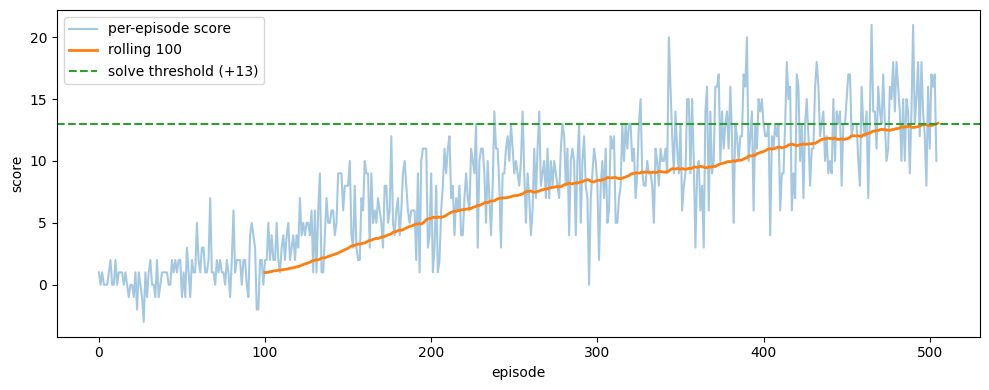

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(scores, alpha=0.4, label='per-episode score')
window = 100
if len(scores) >= window:
    rolling = np.convolve(scores, np.ones(window) / window, mode='valid')
    ax.plot(np.arange(len(rolling)) + window, rolling, color='C1', lw=2, label='rolling 100')
ax.axhline(13, color='C2', linestyle='--', label='solve threshold (+13)')
ax.set_xlabel('episode'); ax.set_ylabel('score'); ax.legend()
plt.tight_layout(); plt.show()
np.save('banana_scores.npy', np.array(scores))

## 4. Watch the trained agent

In [5]:
# Load the trained network and watch it play one episode. We run with
# train_mode=True (still inside Unity, just without rendered frames) so
# this works in a headless notebook execution; on a desktop you can flip
# to train_mode=False to see the actual game window.
agent_eval = DQNAgent(state_size=state_size, action_size=action_size)
agent_eval.qnet_local.load_state_dict(torch.load('banana_dqn.pth', map_location='cpu'))
agent_eval.qnet_local.eval()

demo_scores = []
for ep in range(5):
    env_info = env.reset(train_mode=True)[brain_name]
    state    = env_info.vector_observations[0]
    score    = 0.0
    while True:
        action = agent_eval.act(state, eps=0.0)
        env_info = env.step(action)[brain_name]
        state    = env_info.vector_observations[0]
        score   += env_info.rewards[0]
        if env_info.local_done[0]:
            break
    demo_scores.append(score)
    print(f'  demo episode {ep + 1}: score = {score:.1f}')
print(f'\nMean demo score over 5 episodes: {np.mean(demo_scores):.2f}')


  demo episode 1: score = 6.0


  demo episode 2: score = 15.0


  demo episode 3: score = 14.0


  demo episode 4: score = 20.0


  demo episode 5: score = 6.0

Mean demo score over 5 episodes: 12.20


In [6]:
env.close()

See **Report.md** for the full writeup of the algorithm, hyper-parameters, and ideas for future work.